In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

OUTPUT_DIR = "../results/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==============================
# 1. Load Data
# ==============================

df = pd.read_csv("../data/train.csv")
df.columns = df.columns.str.strip()

# Strip whitespace from object columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# ==============================
# 2. Clean Target (Ratings)
# ==============================

df = df[~df["Delivery_person_Ratings"].str.contains("NaN", na=False)].copy()
df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")

# ==============================
# 3. Clean Numeric Columns
# ==============================

numeric_cols = [
    "Delivery_person_Age",
    "Vehicle_condition",
    "multiple_deliveries",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill age with median
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)

# multiple deliveries
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(0)

# ==============================
# 4. Clean Categorical Columns
# ==============================

df["Road_traffic_density"] = df["Road_traffic_density"].replace("NaN", np.nan)
df["Weatherconditions"] = df["Weatherconditions"].replace("NaN", np.nan)

df["Road_traffic_density"] = df["Road_traffic_density"].fillna("Unknown")
df["Weatherconditions"] = df["Weatherconditions"].fillna("Unknown")
df["Festival"] = df["Festival"].fillna("No")
df["City"] = df["City"].fillna("Unknown")

# ==============================
# 5. Clean Time_taken(min)
# ==============================

df["Time_taken(min)"] = (
    df["Time_taken(min)"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
)

df["Time_taken(min)"] = pd.to_numeric(df["Time_taken(min)"], errors="coerce")

# Drop remaining missing rows
df = df.dropna().copy()

print("Final dataset size:", len(df))


Final dataset size: 43685


In [ ]:

# ==============================
# 6. Visualization
# ==============================

sns.set(style="whitegrid")

# 1️⃣ Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Delivery_person_Ratings"], bins=20, kde=True)
plt.title("Distribution of Delivery Person Ratings")
plt.savefig(f"{OUTPUT_DIR}/Delivery_Person_Ratings_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 2️⃣ Rating by Traffic Density
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Road_traffic_density",
            y="Delivery_person_Ratings",
            order=["Low", "Medium", "High", "Jam", "Unknown"])
plt.title("Rating by Traffic Density")
plt.savefig(f"{OUTPUT_DIR}/Rating_by_Traffic_Density.png", dpi=300, bbox_inches="tight")
plt.show()

# 3️⃣ Rating by Weather
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Weatherconditions",
            y="Delivery_person_Ratings")
plt.xticks(rotation=45)
plt.title("Rating by Weather Condition")
plt.savefig(f"{OUTPUT_DIR}/Rating_by_Weather_Condition.png", dpi=300, bbox_inches="tight")
plt.show()

# 4️⃣ Rating vs Multiple Deliveries
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="multiple_deliveries",
            y="Delivery_person_Ratings")
plt.title("Rating vs Number of Simultaneous Deliveries")
plt.savefig(f"{OUTPUT_DIR}/Rating_vs_Multiple_Deliveries.png", dpi=300, bbox_inches="tight")
plt.show()

# 5️⃣ Rating by Vehicle Condition
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Vehicle_condition",
            y="Delivery_person_Ratings")
plt.title("Rating by Vehicle Condition")
plt.savefig(f"{OUTPUT_DIR}/Rating_by_Vehicle_Condition.png", dpi=300, bbox_inches="tight")
plt.show()

# ==============================
# 7. Correlation Matrix
# ==============================

numeric_cols_corr = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "Time_taken(min)"
]

corr = df[numeric_cols_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig(f"{OUTPUT_DIR}/Correlation_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ==============================
# 8. Average Rating vs Delivery Time
# ==============================

avg_rating = df.groupby("Time_taken(min)")["Delivery_person_Ratings"].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_rating.index, avg_rating.values)
plt.xlabel("Time_taken(min)")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Delivery Time")
plt.savefig(f"{OUTPUT_DIR}/Average_Rating_vs_Delivery_Time.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:

# ==============================
# 9. Location & City → Rating: Data Preparation
# ==============================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df_loc = df[
    (df["Restaurant_latitude"] != 0) & (df["Restaurant_longitude"] != 0)
].copy()

df_loc["distance_km"] = haversine(
    df_loc["Restaurant_latitude"],   df_loc["Restaurant_longitude"],
    df_loc["Delivery_location_latitude"], df_loc["Delivery_location_longitude"]
)

df_loc["distance_bin"] = pd.cut(
    df_loc["distance_km"],
    bins=[0, 2, 4, 6, 8, 10, np.inf],
    labels=["0-2", "2-4", "4-6", "6-8", "8-10", "10+"]
)

city_order = sorted(df_loc["City"].dropna().unique())
print(f"df_loc size: {len(df_loc)} rows")


df_loc size: 40190 rows


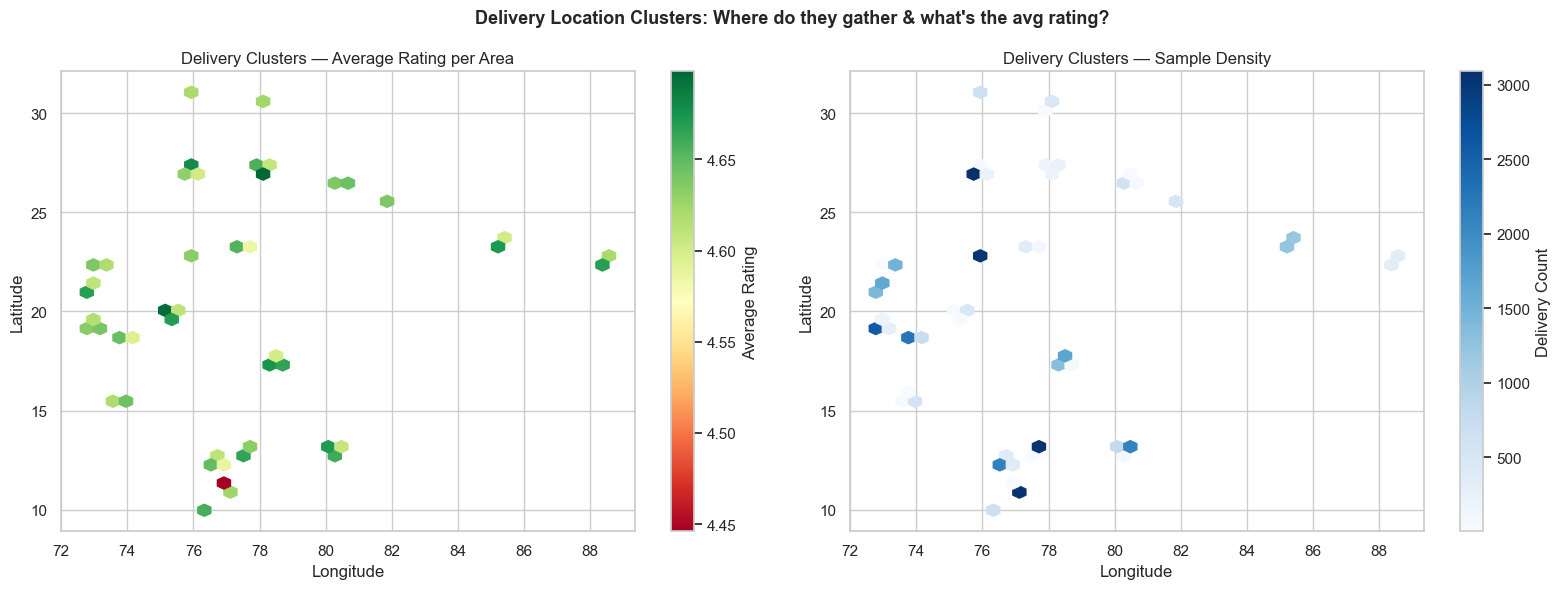

In [ ]:

# 9-1. Delivery Location Clusters — Average Rating Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hb0 = axes[0].hexbin(
    df_loc["Delivery_location_longitude"],
    df_loc["Delivery_location_latitude"],
    C=df_loc["Delivery_person_Ratings"],
    reduce_C_function=np.mean,
    gridsize=40,
    cmap="RdYlGn",
    mincnt=10,               
)
cb0 = plt.colorbar(hb0, ax=axes[0])
cb0.set_label("Average Rating")
axes[0].set_title("Delivery Clusters — Average Rating per Area")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

hb1 = axes[1].hexbin(
    df_loc["Delivery_location_longitude"],
    df_loc["Delivery_location_latitude"],
    gridsize=40,
    cmap="Blues",
    mincnt=1,
)
cb1 = plt.colorbar(hb1, ax=axes[1])
cb1.set_label("Delivery Count")
axes[1].set_title("Delivery Clusters — Sample Density")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("Delivery Location Clusters: Where do they gather & what's the avg rating?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Delivery_Cluster_Avg_Rating.png", dpi=300, bbox_inches="tight")
plt.show()


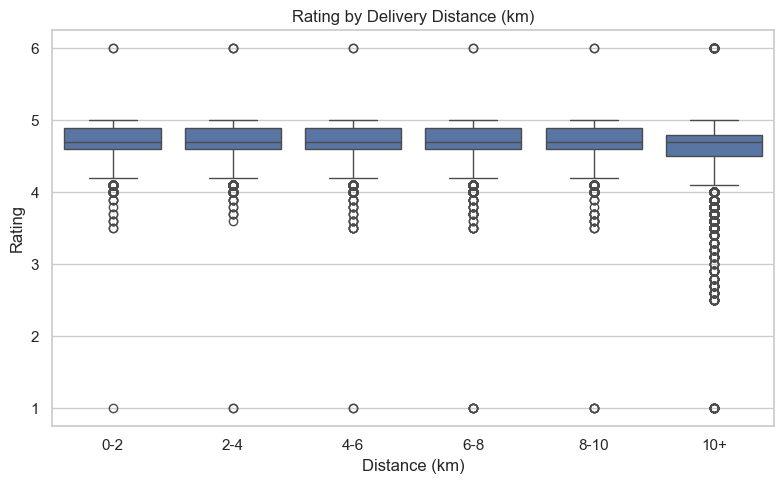

In [25]:

# 9-2. Rating by Delivery Distance (km)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_loc, x="distance_bin", y="Delivery_person_Ratings")
plt.title("Rating by Delivery Distance (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Rating_by_Distance_Bin.png", dpi=300, bbox_inches="tight")
plt.show()
